In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
path = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET"

In [3]:
files = os.listdir("/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion")
print(files)

['utils.py', 'Readme file - Description of Experimental Tests.txt', 'Technical Information and Experimental Test Results for LG 18650HG2.pdf', '10degC', '0degC', '25degC', '40degC', 'n10degC', 'n20degC']


In [4]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [5]:
print(" EDA / PREPROCESSING REVIEW")
day11_output_directory = ("/content/drive/MyDrive/""BATTERY_SOC_PROJECT/day11_outputs")
target_variables = ["SOC","Remaining Charging Time"]
print("\nTargets:")
for target in target_variables:
    print("-", target)
print("\nDay 11 output folder:")
print(day11_output_directory)


 EDA / PREPROCESSING REVIEW

Targets:
- SOC
- Remaining Charging Time

Day 11 output folder:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/day11_outputs


In [6]:
print(" CLEANING RESULTS")
cleaned_dataset_path = os.path.join(day11_output_directory,"cleaned_battery_dataset_day11.csv")
charging_df = pd.read_csv(cleaned_dataset_path)
print("\nFinal charging dataset shape:")
print(charging_df.shape)
print("\nNumber of rows:")
print(len(charging_df))
print("\nNumber of columns:")
print(len(charging_df.columns))
print("\nColumns:")
print(list(charging_df.columns))
print("\nMissing values:")
print(charging_df.isnull().sum())
print("\nDuplicate rows:")
print(charging_df.duplicated().sum())
if "Charging_Session" in charging_df.columns:
    print("\nNumber of charging sessions:")
    print(charging_df["Charging_Session"].nunique())
if "Source_File" in charging_df.columns:
    print("\nNumber of source files:")
    print(charging_df["Source_File"].nunique())

 CLEANING RESULTS

Final charging dataset shape:
(4949249, 19)

Number of rows:
4949249

Number of columns:
19

Columns:
['Time Stamp', 'Step', 'Status', 'Prog Time', 'Step Time', 'Cycle', 'Cycle Level', 'Procedure', 'Voltage', 'Current', 'Temperature', 'Capacity', 'WhAccu', 'Cnt', 'Source_File', '_status_change', '_file_change', '_new_session', 'Charging_Session']

Missing values:
Time Stamp          208
Step                208
Status              208
Prog Time           208
Step Time           208
Cycle               208
Cycle Level         208
Procedure           208
Voltage             210
Current             210
Temperature         210
Capacity            210
WhAccu              210
Cnt                 211
Source_File           0
_status_change        0
_file_change          0
_new_session          0
Charging_Session      0
dtype: int64

Duplicate rows:
0

Number of charging sessions:
1931

Number of source files:
208


In [7]:
print(" TARGET DISTRIBUTIONS")

# SOC distribution
if "SOC" in charging_df.columns:
    print("\nSOC statistics:")
    print(charging_df["SOC"].describe())
    plt.figure(figsize=(8, 5))
    plt.hist(charging_df["SOC"].dropna(),bins=30)
    plt.xlabel("SOC (%)")
    plt.ylabel("Frequency")
    plt.title("SOC Distribution")
    plt.grid(True, alpha=0.3)
    plt.show()
# Remaining Charging Time distribution
if "Remaining Charging Time" in charging_df.columns:
    print("\nRemaining Charging Time statistics:")
    print(charging_df["Remaining Charging Time"].describe())
    plt.figure(figsize=(8, 5))
    plt.hist(charging_df["Remaining Charging Time"].dropna(),bins=30)
    plt.xlabel("Remaining Charging Time (seconds)")
    plt.ylabel("Frequency")
    plt.title("Remaining Charging Time Distribution")
    plt.grid(True, alpha=0.3)
    plt.show()

 TARGET DISTRIBUTIONS


In [10]:
print(" TARGET RANGE CHECK")
if "SOC" in charging_df.columns:
    print("\nSOC range:")
    print("Minimum:", charging_df["SOC"].min())
    print("Maximum:", charging_df["SOC"].max())
    invalid_soc = (
        (charging_df["SOC"] < 0) |
        (charging_df["SOC"] > 100)
    ).sum()
    print("SOC values outside 0–100:", invalid_soc)
if "Remaining Charging Time" in charging_df.columns:
    print("\nRemaining Charging Time range:")
    print("Minimum:",charging_df["Remaining Charging Time"].min())
    print("Maximum:",charging_df["Remaining Charging Time"].max())
    negative_time = (charging_df["Remaining Charging Time"] < 0).sum()
    print("Negative remaining-time values:",negative_time)

 TARGET RANGE CHECK


 CORRELATION ANALYSIS

SOC correlation matrix:


,Voltage,Current,Temperature,Cycle,WhAccu
Voltage,1.000000,0.351425,0.155449,-0.088199,0.798953
Current,0.351425,1.000000,0.017117,-0.022124,-0.005756
Temperature,0.155449,0.017117,1.000000,0.081660,-0.161785
Cycle,-0.088199,-0.022124,0.081660,1.000000,-0.166586
WhAccu,0.798953,-0.005756,-0.161785,-0.166586,1.000000


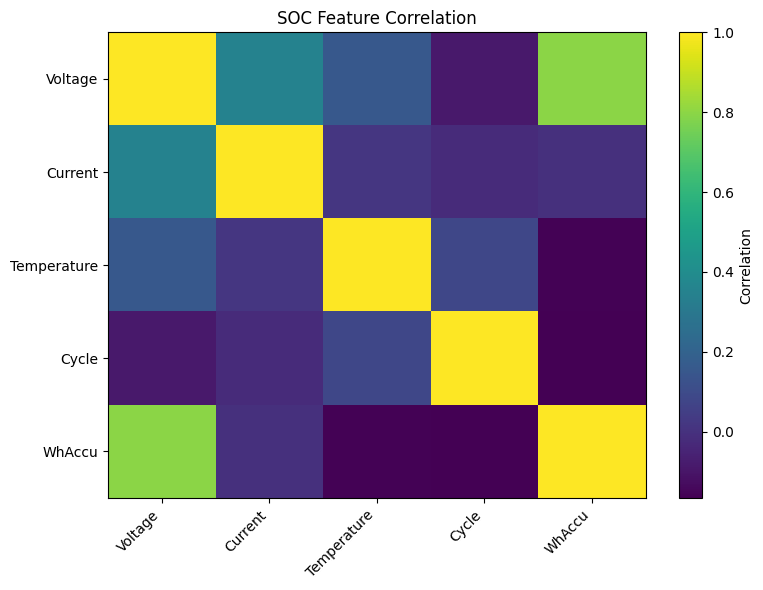


Remaining Charging Time correlation matrix:


,Voltage,Current,Temperature,Cycle,Capacity,WhAccu
Voltage,1.000000,0.351425,0.155449,-0.088199,0.820994,0.798953
Current,0.351425,1.000000,0.017117,-0.022124,-0.007432,-0.005756
Temperature,0.155449,0.017117,1.000000,0.081660,-0.107655,-0.161785
Cycle,-0.088199,-0.022124,0.081660,1.000000,-0.152838,-0.166586
Capacity,0.820994,-0.007432,-0.107655,-0.152838,1.000000,0.996742
WhAccu,0.798953,-0.005756,-0.161785,-0.166586,0.996742,1.000000


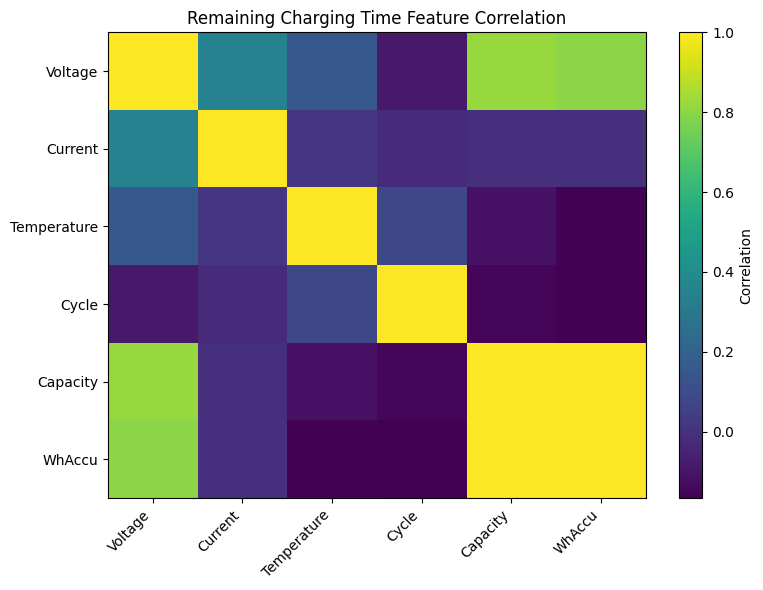

In [11]:
print(" CORRELATION ANALYSIS")
soc_input_variables = ["Voltage","Current","Temperature","Elapsed Time","Cycle"]

time_input_variables = ["Voltage","Current","Temperature","Elapsed Time","Cycle","Capacity"]
if "WhAccu" in charging_df.columns:
    soc_input_variables.append("WhAccu")
    time_input_variables.append("WhAccu")
soc_columns = [
    col for col in soc_input_variables + ["SOC"]
    if col in charging_df.columns]
time_columns = [col for col in time_input_variables +["Remaining Charging Time"]
    if col in charging_df.columns
]

soc_correlation = charging_df[soc_columns].corr()
print("\nSOC correlation matrix:")
display(soc_correlation)
soc_correlation_path = os.path.join(day11_output_directory,"SOC_correlation_day12.csv")
soc_correlation.to_csv(soc_correlation_path)
plt.figure(figsize=(8, 6))
plt.imshow(soc_correlation,aspect="auto")
plt.xticks(range(len(soc_correlation.columns)),soc_correlation.columns,rotation=45,ha="right")
plt.yticks(range(len(soc_correlation.index)),soc_correlation.index)
plt.colorbar(label="Correlation")
plt.title("SOC Feature Correlation")
plt.tight_layout()
plt.show()


time_correlation = charging_df[time_columns].corr()
print("\nRemaining Charging Time correlation matrix:")
display(time_correlation)
time_correlation_path = os.path.join(day11_output_directory,"remaining_time_correlation_day12.csv")
time_correlation.to_csv(time_correlation_path)
plt.figure(figsize=(8, 6))
plt.imshow(time_correlation,aspect="auto")
plt.xticks(range(len(time_correlation.columns)),time_correlation.columns,rotation=45,ha="right")
plt.yticks(range(len(time_correlation.index)),time_correlation.index)
plt.colorbar(label="Correlation")
plt.title("Remaining Charging Time Feature Correlation")
plt.tight_layout()
plt.show()

In [12]:
print(" BASIC DATA LEAKAGE REVIEW")

print("\nSOC target:")
print("SOC")
print("SOC input features:")
print(soc_input_variables)

print("\nRemaining Charging Time target:")
print("Remaining Charging Time")
print("Remaining-time input features:")
print(time_input_variables)

if "SOC" not in soc_input_variables:
    print("\n✓ SOC is not included as an SOC input feature.")
else:
    print("\n⚠ SOC appears in its own feature list.")

if "Remaining Charging Time" not in time_input_variables:
    print("✓ Remaining Charging Time is not an input feature.")
else:
    print("⚠ Remaining Charging Time appears in its feature list.")

split_files = {
    "SOC Train": "SOC_train_day11.csv",
    "SOC Validation": "SOC_validation_day11.csv",
    "SOC Test": "SOC_test_day11.csv",
    "Time Train": "remaining_time_train_day11.csv",
    "Time Validation": "remaining_time_validation_day11.csv",
    "Time Test": "remaining_time_test_day11.csv"
}

loaded_splits = {}
for name, file_name in split_files.items():
    path = os.path.join(day11_output_directory,file_name)
    loaded_splits[name] = pd.read_csv(path)
print("\nSource_File overlap checks:")
for group1, group2 in [
    ("SOC Train", "SOC Validation"),
    ("SOC Train", "SOC Test"),
    ("SOC Validation", "SOC Test"),
    ("Time Train", "Time Validation"),
    ("Time Train", "Time Test"),
    ("Time Validation", "Time Test")
]:
    if (
        "Source_File" in loaded_splits[group1].columns and
        "Source_File" in loaded_splits[group2].columns
    ):
        overlap = set(
            loaded_splits[group1]["Source_File"].dropna()
        ).intersection(
            set(
                loaded_splits[group2]["Source_File"].dropna()
            )
        )
        print(
            f"{group1} vs {group2}:",
            len(overlap),
            "overlapping source files"
        )

 BASIC DATA LEAKAGE REVIEW

SOC target:
SOC
SOC input features:
['Voltage', 'Current', 'Temperature', 'Elapsed Time', 'Cycle', 'WhAccu']

Remaining Charging Time target:
Remaining Charging Time
Remaining-time input features:
['Voltage', 'Current', 'Temperature', 'Elapsed Time', 'Cycle', 'Capacity', 'WhAccu']

✓ SOC is not included as an SOC input feature.
✓ Remaining Charging Time is not an input feature.

Source_File overlap checks:
SOC Train vs SOC Validation: 0 overlapping source files
SOC Train vs SOC Test: 0 overlapping source files
SOC Validation vs SOC Test: 0 overlapping source files
Time Train vs Time Validation: 0 overlapping source files
Time Train vs Time Test: 0 overlapping source files
Time Validation vs Time Test: 0 overlapping source files


In [15]:
print(" APPROVED PREPROCESSING DECISIONS")
preprocessing_decisions = pd.DataFrame({
    "Decision": ["Missing numerical values","Feature scaling","Data splitting","Group variable","SOC target","Remaining charging time target","Feature engineering","Final feature selection"],
    "Decision Made": ["StandardScaler","Train / Validation / Test","Source_File","Session-based" ,"SOC percentage","Time remaining until final charging timestamp","Will be evaluated","Will be finalized after further analysis"],
    "Reason": ["Robust to outliers and simple for numerical data","Places numerical features on a comparable scale","Keeps separate data for training and evaluation","Reduces the chance of the same source file appearing in multiple splits","Provides a normalized SOC target from charging capacity","Provides a supervised remaining-time target","Will be evaluated during feature engineering","Will be finalized after further analysis"]
})

display(preprocessing_decisions)
decisions_path = os.path.join(
    day11_output_directory,
    "preprocessing_decisions_day12.csv"
)
preprocessing_decisions.to_csv(decisions_path,index=False)
print("\nSaved:")
print(decisions_path)

 APPROVED PREPROCESSING DECISIONS


,Decision,Decision Made,Reason
0,Missing numerical values,StandardScaler,Robust to outliers and simple for numerical data
1,Feature scaling,Train / Validation / Test,Places numerical features on a comparable scale
2,Data splitting,Source_File,Keeps separate data for training and evaluation
3,Group variable,Session-based,Reduces the chance of the same source file app...
4,SOC target,SOC percentage,Provides a normalized SOC target from charging...
5,Remaining charging time target,Time remaining until final charging timestamp,Provides a supervised remaining-time target
6,Feature engineering,Will be evaluated,Will be evaluated during feature engineering
7,Final feature selection,Will be finalized after further analysis,Will be finalized after further analysis



Saved:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/day11_outputs/preprocessing_decisions_day12.csv


In [16]:
print(" TRAIN / VALIDATION ")

soc_train = pd.read_csv(os.path.join(day11_output_directory,"SOC_train_day11.csv"))
soc_validation = pd.read_csv(os.path.join(day11_output_directory,"SOC_validation_day11.csv"))
soc_test = pd.read_csv(os.path.join(day11_output_directory,"SOC_test_day11.csv"))


time_train = pd.read_csv(os.path.join( day11_output_directory,"remaining_time_train_day11.csv"))
time_validation = pd.read_csv(os.path.join(day11_output_directory,"remaining_time_validation_day11.csv"))
time_test = pd.read_csv(os.path.join(day11_output_directory,"remaining_time_test_day11.csv"))

print("\nSOC split sizes:")
print("Train:", soc_train.shape)
print("Validation:", soc_validation.shape)
print("Test:", soc_test.shape)
print("\nRemaining-time split sizes:")
print("Train:", time_train.shape)
print("Validation:", time_validation.shape)
print("Test:", time_test.shape)
total_soc = (len(soc_train) +len(soc_validation) +len(soc_test))
total_time = (len(time_train) +len(time_validation) +len(time_test))
print("\nTotal SOC rows:", total_soc)
print("Total remaining-time rows:", total_time)

 TRAIN / VALIDATION 

SOC split sizes:
Train: (9926, 9)
Validation: (7376, 9)
Test: (2250, 9)

Remaining-time split sizes:
Train: (41015, 10)
Validation: (1349, 10)
Test: (2286, 10)

Total SOC rows: 19552
Total remaining-time rows: 44650


In [17]:
print("PREPROCESSING PIPELINE REVIEW")
import joblib
soc_pipeline_path = os.path.join(day11_output_directory,"SOC_preprocessing_pipeline_day11.joblib")
time_pipeline_path = os.path.join(day11_output_directory,"remaining_time_preprocessing_pipeline_day11.joblib")
soc_pipeline = joblib.load(soc_pipeline_path)
time_pipeline = joblib.load(time_pipeline_path)
print("\n✓ SOC preprocessing pipeline loaded")
print("✓ Remaining-time preprocessing pipeline loaded")

soc_features = [
    col for col in soc_input_variables
    if col in soc_train.columns
]
soc_target = "SOC"
X_soc_train = soc_train[soc_features]
X_soc_validation = soc_validation[soc_features]
X_soc_test = soc_test[soc_features]
y_soc_train = soc_train[soc_target]
y_soc_validation = soc_validation[soc_target]
y_soc_test = soc_test[soc_target]
X_soc_train_processed = soc_pipeline.transform(X_soc_train)
X_soc_validation_processed = soc_pipeline.transform(X_soc_validation)
X_soc_test_processed = soc_pipeline.transform(X_soc_test)

time_features = [
    col for col in time_input_variables
    if col in time_train.columns
]

time_target = "Remaining Charging Time"
X_time_train = time_train[time_features]
X_time_validation = time_validation[time_features]
X_time_test = time_test[time_features]

y_time_train = time_train[time_target]
y_time_validation = time_validation[time_target]
y_time_test = time_test[time_target]


X_time_train_processed = time_pipeline.transform(X_time_train)
X_time_validation_processed = time_pipeline.transform(X_time_validation)
X_time_test_processed = time_pipeline.transform(X_time_test)

print("\nSOC processed feature shape:")
print(X_soc_train_processed.shape)
print("\nRemaining-time processed feature shape:")
print(X_time_train_processed.shape)
print("\nNaN check:")
print("SOC train:",np.isnan(X_soc_train_processed).sum())
print("SOC validation:",np.isnan(X_soc_validation_processed).sum())
print("SOC test:",np.isnan(X_soc_test_processed).sum())
print("Time train:",np.isnan(X_time_train_processed).sum())
print("Time validation:",np.isnan(X_time_validation_processed).sum())
print("Time test:",np.isnan(X_time_test_processed).sum())



PREPROCESSING PIPELINE REVIEW

✓ SOC preprocessing pipeline loaded
✓ Remaining-time preprocessing pipeline loaded

SOC processed feature shape:
(9926, 6)

Remaining-time processed feature shape:
(41015, 7)

NaN check:
SOC train: 0
SOC validation: 0
SOC test: 0
Time train: 0
Time validation: 0
Time test: 0


In [18]:
print("FREEZE DATASET V1")
day12_output_directory = ("/content/drive/MyDrive/""BATTERY_SOC_PROJECT/day12_dataset_V1")

os.makedirs(
    day12_output_directory,
    exist_ok=True
)

charging_df.to_csv(
    os.path.join(day12_output_directory,"cleaned_battery_dataset_day12_V1.csv"),index=False)

soc_train.to_csv(
    os.path.join(day12_output_directory,"SOC_train_day12_V1.csv"),index=False)

soc_validation.to_csv(
    os.path.join(day12_output_directory,"SOC_validation_day12_V1.csv"),index=False)

soc_test.to_csv(
    os.path.join(day12_output_directory,"SOC_test_day12_V1.csv"),index=False)

time_train.to_csv(
    os.path.join(day12_output_directory,"remaining_time_train_day12_V1.csv"),index=False)

time_validation.to_csv(
    os.path.join(day12_output_directory,"remaining_time_validation_day12_V1.csv"),index=False)

time_test.to_csv(
    os.path.join(day12_output_directory,"remaining_time_test_day12_V1.csv"),index=False)

soc_correlation.to_csv(
    os.path.join(
        day12_output_directory,
        "SOC_correlation_day12_V1.csv"
    )
)

time_correlation.to_csv(
    os.path.join(day12_output_directory,"remaining_time_correlation_day12_V1.csv"))


preprocessing_decisions.to_csv(
    os.path.join(day12_output_directory,"preprocessing_decisions_day12_V1.csv"),index=False)

import shutil
shutil.copy2(
    soc_pipeline_path,
    os.path.join(day12_output_directory,"SOC_preprocessing_pipeline_day12_V1.joblib"))
shutil.copy2(
    time_pipeline_path,
    os.path.join(day12_output_directory,"remaining_time_preprocessing_pipeline_day12_V1.joblib"))

day12_metadata = {
    "project": ("Battery SOC Estimation and Remaining Charging ""Time Prediction using ML"),
    "dataset_version": "Day 12 Dataset V1",
    "source": "Day 11 processed dataset",
    "targets": ["SOC","Remaining Charging Time"],
    "soc_input_variables": soc_features,
    "time_input_variables": time_features,
    "group_variable": "Source_File",
    "preprocessing": ["Median imputation","StandardScaler"],
    "feature_engineering": "Reserved for Day 13",
    "final_feature_selection": "Reserved for Day 13"
}
with open(
    os.path.join(
        day12_output_directory,
        "metadata_day12_V1.json"
    ),
    "w"
) as file:
    json.dump(
        day12_metadata,
        file,
        indent=4
    )

print("\nDataset V1 saved successfully.")
print("\nDay 12 output folder:")
print(day12_output_directory)
print("\nFiles created:")
for file_name in sorted(
    os.listdir(day12_output_directory)
):
    print("-", file_name)
print(" DATASET V1 — FROZEN SUCCESSFULLY ✓")


FREEZE DATASET V1

Dataset V1 saved successfully.

Day 12 output folder:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/day12_dataset_V1

Files created:
- SOC_correlation_day12_V1.csv
- SOC_preprocessing_pipeline_day12_V1.joblib
- SOC_test_day12_V1.csv
- SOC_train_day12_V1.csv
- SOC_validation_day12_V1.csv
- cleaned_battery_dataset_day12_V1.csv
- metadata_day12_V1.json
- preprocessing_decisions_day12_V1.csv
- remaining_time_correlation_day12_V1.csv
- remaining_time_preprocessing_pipeline_day12_V1.joblib
- remaining_time_test_day12_V1.csv
- remaining_time_train_day12_V1.csv
- remaining_time_validation_day12_V1.csv
 DATASET V1 — FROZEN SUCCESSFULLY ✓
